# 📜 Data Contract Validator

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-engineering-pro/data-contract-validator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-engineering-pro/data-contract-validator/demo.ipynb)

**Pain point:** *"Producers break schemas without warning."*

A YAML contract per dataset + a validator with CI exit-code semantics: producers can't merge a change that breaks consumers, and datasets can't land violating the contract.

**What this notebook covers:**
1. The contract format and validator
2. Validating a dataset with five planted violations
3. Contract-version diff — breaking vs safe changes
4. Visualizing violations
5. Try your own contract


## Step 1 — Contract + validator

A contract declares, per column: `type`, `nullable`, `unique`, `allowed` values, `min`/`max` bounds — plus dataset-level `freshness` (newest row must be younger than N hours).

Two checks, both with CI semantics (`exit 1` on any error):
- **`validate_dataset`** — data vs contract: run it where the data lands.
- **`diff_contracts`** — old vs new contract version: run it in the producer's PR. Removing a column or changing a type = breaking (error); adding an optional column = safe (warning).


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional

import pandas as pd
import yaml

TYPE_CHECKS = {
    "int": pd.api.types.is_integer_dtype,
    "float": lambda s: pd.api.types.is_float_dtype(s) or pd.api.types.is_integer_dtype(s),
    "string": lambda s: pd.api.types.is_object_dtype(s) or pd.api.types.is_string_dtype(s),
    "datetime": pd.api.types.is_datetime64_any_dtype,
    "bool": pd.api.types.is_bool_dtype,
}


@dataclass
class Violation:
    level: str  # error | warning
    column: str
    rule: str
    detail: str


def load_contract(text: str) -> Dict:
    return yaml.safe_load(text)


def validate_dataset(df: pd.DataFrame, contract: Dict) -> List[Violation]:
    """Check a dataset against its contract. Errors fail the build; warnings inform."""
    v: List[Violation] = []
    cols = {c["name"]: c for c in contract.get("columns", [])}

    for name, spec in cols.items():
        if name not in df.columns:
            v.append(Violation("error", name, "missing-column", "column absent from dataset"))
            continue
        s = df[name]
        ctype = spec.get("type", "string")
        check = TYPE_CHECKS.get(ctype)
        series = s
        if ctype == "datetime" and pd.api.types.is_object_dtype(s):
            parsed = pd.to_datetime(s, errors="coerce", format="mixed")
            if parsed.notna().mean() > 0.99:
                series = parsed
        if check and not check(series):
            v.append(Violation("error", name, "type-mismatch",
                               f"expected {ctype}, got {s.dtype}"))
            continue
        if not spec.get("nullable", True):
            nulls = int(s.isna().sum())
            if nulls:
                v.append(Violation("error", name, "null-violation",
                                   f"{nulls} nulls in non-nullable column"))
        if spec.get("unique"):
            dupes = int(s.duplicated().sum())
            if dupes:
                v.append(Violation("error", name, "uniqueness", f"{dupes} duplicate values"))
        allowed = spec.get("allowed")
        if allowed:
            bad = s.dropna()[~s.dropna().isin(allowed)]
            if len(bad):
                v.append(Violation("error", name, "allowed-values",
                                   f"{len(bad)} rows outside {allowed} (e.g. {bad.iloc[0]!r})"))
        if "min" in spec:
            below = int((pd.to_numeric(s, errors="coerce") < spec["min"]).sum())
            if below:
                v.append(Violation("error", name, "min-bound", f"{below} rows below min={spec['min']}"))
        if "max" in spec:
            above = int((pd.to_numeric(s, errors="coerce") > spec["max"]).sum())
            if above:
                v.append(Violation("error", name, "max-bound", f"{above} rows above max={spec['max']}"))

    extra = [c for c in df.columns if c not in cols]
    for name in extra:
        v.append(Violation("warning", name, "undeclared-column",
                           "column present but not in contract — declare it or drop it"))

    fresh = contract.get("freshness")
    if fresh:
        col, max_age_h = fresh["column"], fresh["max_age_hours"]
        if col in df.columns:
            newest = pd.to_datetime(df[col], errors="coerce", format="mixed").max()
            asof = pd.Timestamp(fresh.get("as_of")) if fresh.get("as_of") else pd.Timestamp.now()
            age_h = (asof - newest).total_seconds() / 3600
            if age_h > max_age_h:
                v.append(Violation("error", col, "freshness",
                                   f"newest row is {age_h:.1f}h old (max {max_age_h}h)"))
    return v


def diff_contracts(old: Dict, new: Dict) -> List[Violation]:
    """Compare contract versions: what would break consumers vs what's safe."""
    v: List[Violation] = []
    old_cols = {c["name"]: c for c in old.get("columns", [])}
    new_cols = {c["name"]: c for c in new.get("columns", [])}

    for name, spec in old_cols.items():
        if name not in new_cols:
            v.append(Violation("error", name, "breaking:removed", "column removed — consumers will break"))
            continue
        ns = new_cols[name]
        if ns.get("type") != spec.get("type"):
            v.append(Violation("error", name, "breaking:type-change",
                               f"{spec.get('type')} → {ns.get('type')}"))
        if spec.get("nullable", True) is False and ns.get("nullable", True) is True:
            v.append(Violation("error", name, "breaking:nullable-loosened",
                               "non-nullable became nullable — consumer assumptions break"))
        if ns.get("nullable", True) is False and spec.get("nullable", True) is True:
            v.append(Violation("warning", name, "tightened:nullable",
                               "nullable became non-nullable — safe for consumers, hard for producer"))
    for name, ns in new_cols.items():
        if name in old_cols:
            continue
        if ns.get("nullable", True):
            v.append(Violation("warning", name, "safe:added-optional", "new optional column — non-breaking"))
        else:
            v.append(Violation("error", name, "breaking:added-required",
                               "new required column — old producers will fail validation"))
    return v


def exit_code(violations: List[Violation]) -> int:
    """CI semantics: 1 if any error, else 0."""
    return 1 if any(x.level == "error" for x in violations) else 0


def report(violations: List[Violation]) -> str:
    if not violations:
        return "✅ contract check passed — no violations"
    lines = []
    for x in sorted(violations, key=lambda x: (x.level != "error", x.column)):
        icon = "✗" if x.level == "error" else "⚠"
        lines.append(f"{icon} [{x.level:7s}] {x.column}: {x.rule} — {x.detail}")
    n_err = sum(1 for x in violations if x.level == "error")
    lines.append(f"\n{n_err} error(s), {len(violations) - n_err} warning(s) → exit {exit_code(violations)}")
    return "\n".join(lines)


## Step 2 — Validate a dataset with planted violations

The orders contract: unique non-null `order_id`, `amount ≥ 0`, `status` in an enum, fresh `created_at`. The CSV plants five problems.

In [2]:
import io
import pandas as pd

CONTRACT = """dataset: orders
owner: checkout-team
columns:
  - name: order_id
    type: string
    nullable: false
    unique: true
  - name: amount
    type: float
    nullable: false
    min: 0
  - name: status
    type: string
    allowed: [pending, paid, shipped, cancelled]
  - name: created_at
    type: datetime
    nullable: false
freshness:
  column: created_at
  max_age_hours: 24
  as_of: 2026-07-11 12:00:00
"""

CSV = """order_id,amount,status,created_at,coupon_code
ord-1,25.00,paid,2026-07-11 09:00:00,SAVE10
ord-2,-4.00,paid,2026-07-11 09:05:00,
ord-3,60.00,refunded,2026-07-11 09:10:00,
ord-3,60.00,paid,2026-07-11 09:12:00,
ord-5,,pending,2026-07-11 09:20:00,
"""

contract = load_contract(CONTRACT)
df = pd.read_csv(io.StringIO(CSV))
violations = validate_dataset(df, contract)
print(report(violations))

✗ [error  ] amount: null-violation — 1 nulls in non-nullable column
✗ [error  ] amount: min-bound — 1 rows below min=0
✗ [error  ] order_id: uniqueness — 1 duplicate values
✗ [error  ] status: allowed-values — 1 rows outside ['pending', 'paid', 'shipped', 'cancelled'] (e.g. 'refunded')
⚠ [warning] coupon_code: undeclared-column — column present but not in contract — declare it or drop it

4 error(s), 1 warning(s) → exit 1


## Step 3 — Contract diff: catch breaking changes in the producer's PR

The producer proposes v2: `amount` becomes a string and `status` disappears. Both would silently break every consumer — the diff blocks the merge.

In [3]:
new_contract = load_contract(CONTRACT.replace("type: float", "type: string"))
del new_contract["columns"][2]          # drop 'status'
new_contract["columns"].append({"name": "channel", "type": "string", "nullable": True})

changes = diff_contracts(contract, new_contract)
print(report(changes))

✗ [error  ] amount: breaking:type-change — float → string
✗ [error  ] status: breaking:removed — column removed — consumers will break
⚠ [warning] channel: safe:added-optional — new optional column — non-breaking

2 error(s), 1 warning(s) → exit 1


## Step 4 — Visualize violations

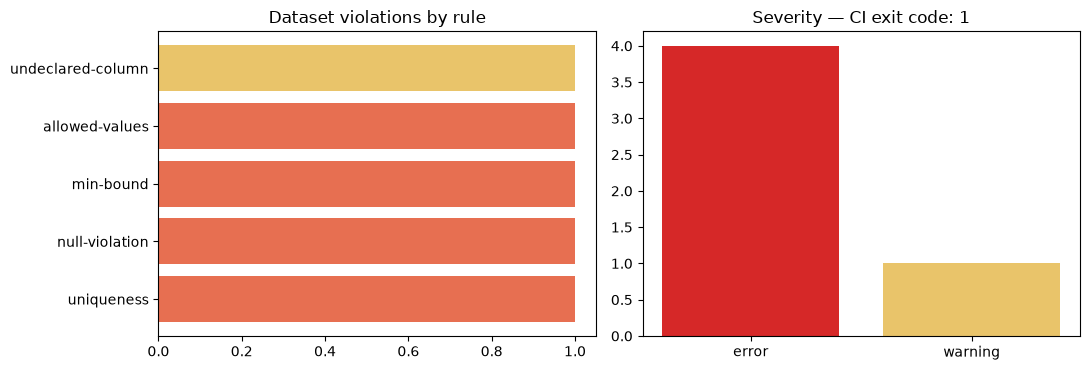

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

rules = Counter(v.rule for v in violations)
levels = Counter(v.level for v in violations)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))
items = sorted(rules.items(), key=lambda kv: kv[1])
ax1.barh([k for k, _ in items], [v for _, v in items],
         color=["#e9c46a" if "undeclared" in k else "#e76f51" for k, _ in items])
ax1.set_title("Dataset violations by rule")

ax2.bar(["error", "warning"], [levels.get("error", 0), levels.get("warning", 0)],
        color=["#d62828", "#e9c46a"])
ax2.set_title(f"Severity — CI exit code: {exit_code(violations)}")

fig.tight_layout()
fig.savefig("contract_violations.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Check | Where it runs | Catches |
|---|---|---|
| `validate_dataset` | where data lands (Airflow task, ingestion job) | nulls, dupes, enum drift, bounds, staleness, surprise columns |
| `diff_contracts` | producer's PR (CI) | removed columns, type changes, loosened nullability |

The sample run: 4 errors + 1 warning on the dataset (exit 1), and the proposed contract v2 flagged with two breaking changes before it ever ships. This is the data-mesh idea made concrete: **producers own quality, and the contract is the enforcement point.**


## Try your own

In [5]:
# my_contract = load_contract("""dataset: users
# columns:
#   - name: user_id
#     type: int
#     nullable: false
#     unique: true
#   - name: email
#     type: string
#     nullable: false
# """)
# my_df = pd.read_csv("users.csv")
# print(report(validate_dataset(my_df, my_contract)))

---

Part of **[Phoebe the Builder](https://github.com/phoebefu6/phoebe-the-builder)** — Portfolio 2: routine data/AI task coverage.

Prefer a UI? Run the Streamlit version:

```bash
pip install -r requirements.txt
streamlit run app.py
```
